## NAME: SHEERAZ AHMED
## CMS ID: 023-24-0171
## SEC: F
## Github: https://github.com/sheerazshyk671/ML_Labs
## Kaggle: https://www.kaggle.com/shazzyahmed
## Dataset: House Prices — Advanced Regression Techniques
## Dataset Source: https://kaggle.com/competitions/house-prices-advanced-regression-techniques

## ML LAB 5

# Part 1 — Dataset, Problem & Feature/Target Identification

**Task 1**

In [ ]:
import pandas as pd
df=pd.read_csv('train.csv')
selected_cols=['OverallQual','GrLivArea','TotalBsmtSF','GarageCars','YearBuilt','FullBath','Neighborhood','HouseStyle','KitchenQual','CentralAir','SalePrice']
df_subset=df[selected_cols].dropna().copy()
print(df_subset.shape)
print(df_subset.dtypes)
print(df_subset.describe())
display(df_subset.head())

(1460, 11)
OverallQual      int64
GrLivArea        int64
TotalBsmtSF      int64
GarageCars       int64
YearBuilt        int64
FullBath         int64
Neighborhood    object
HouseStyle      object
KitchenQual     object
CentralAir      object
SalePrice        int64
dtype: object
       OverallQual    GrLivArea  TotalBsmtSF   GarageCars    YearBuilt  \
count  1460.000000  1460.000000  1460.000000  1460.000000  1460.000000   
mean      6.099315  1515.463699  1057.429452     1.767123  1971.267808   
std       1.382997   525.480383   438.705324     0.747315    30.202904   
min       1.000000   334.000000     0.000000     0.000000  1872.000000   
25%       5.000000  1129.500000   795.750000     1.000000  1954.000000   
50%       6.000000  1464.000000   991.500000     2.000000  1973.000000   
75%       7.000000  1776.750000  1298.250000     2.000000  2000.000000   
max      10.000000  5642.000000  6110.000000     4.000000  2010.000000   

          FullBath      SalePrice  
count  1460.000000 

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,Neighborhood,HouseStyle,KitchenQual,CentralAir,SalePrice
0,7,1710,856,2,2003,2,CollgCr,2Story,Gd,Y,208500
1,6,1262,1262,2,1976,2,Veenker,1Story,TA,Y,181500
2,7,1786,920,2,2001,2,CollgCr,2Story,Gd,Y,223500
3,7,1717,756,3,1915,1,Crawfor,2Story,Gd,Y,140000
4,8,2198,1145,3,2000,2,NoRidge,2Story,Gd,Y,250000


**Task 2**

Dependent Variable is: SalePrice

Numerical Independent Variables are: OverallQual GrLivArea TotalBsmtSF GarageCars YearBuilt FullBath

Categorical Independent Variables are: Neighborhood HouseStyle KitchenQual CentralAir

**Task 3**

This is a regression problem because the target variable is a continuous numerical value representing a monetary amount rather than a discrete class label Consequently we evaluate the model using error distance metrics like Mean Absolute Error and Root Mean Squared Error instead of classification metrics like accuracy or precision

# Part 2 — Data Preparation & Train/Test Split

**Task 4**

I used mapping for CentralAir because it is a binary column requiring a simple numerical conversion For Neighborhood HouseStyle and KitchenQual I used one hot encoding with pd get_dummies because they have multiple categories and linear regression needs fully numeric inputs without assuming any false ranking among the categories

In [ ]:
from sklearn.model_selection import train_test_split
df_subset['CentralAir']=df_subset['CentralAir'].map({'Y':1,'N':0})
X=pd.get_dummies(df_subset.drop('SalePrice',axis=1),columns=['Neighborhood','HouseStyle','KitchenQual'],drop_first=True,dtype=int)
y=df_subset['SalePrice']
print(X.isnull().sum().sum())
print(X.dtypes.unique())
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

0
[dtype('int64')]
(1168, 41)
(292, 41)


**Task 5**

The code outputs confirm that the sum of all missing values is 0 and all columns are now strictly numeric data types

**Task 6**

The data is successfully split into an 80 20 ratio using train_test_split The printed shapes show the exact number of rows and columns for the training and testing sets

# Part 3 — Linear Regression & Predictions

**Task 7 and 8**

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
comparison=pd.DataFrame({'ActualPrice':y_test,'PredictedPrice':y_pred})
display(comparison.head(10))

,ActualPrice,PredictedPrice
892,154500,137659.433698
1105,325000,322497.734150
413,115000,115957.464766
522,159000,173739.263181
1036,315500,315646.862874
614,75500,67354.357813
218,311500,232152.147150
1160,146000,146898.781791
649,84500,66987.286001
887,135500,118002.475352


# Part 4 — Coefficients & Intercept

**Task 9**

for each one unit increase in a numerical feature the sale price changes by the exact coefficient value assuming all other features remain constant

In [ ]:
intercept=lr.intercept_
print(intercept)
coef_df=pd.DataFrame({'Feature':X.columns,'Coefficient':lr.coef_})
display(coef_df)

-364075.4945224427


,Feature,Coefficient
0,OverallQual,12729.219420
1,GrLivArea,56.594586
2,TotalBsmtSF,5.371465
3,GarageCars,11155.567741
4,YearBuilt,183.535906
5,FullBath,369.460804
6,CentralAir,12044.993591
7,Neighborhood_Blueste,851.359337
8,Neighborhood_BrDale,-1710.964102
9,Neighborhood_BrkSide,22714.997977


**Task 10**

The intercept represents the predicted base price of a house if all independent variables were exactly zero This does not have a sensible real world interpretation for this dataset because a house cannot mathematically have zero square footage or be built in the year zero

# Part 5 — Residuals & Regression Metrics

**Task 11 and 12**

based on the scatter plot there is a clear visible pattern where the residuals fan out as the predicted price increases meaning the model makes much larger mistakes on expensive houses the histogram also shows a right skew confirming it underpredicts some very high priced homes

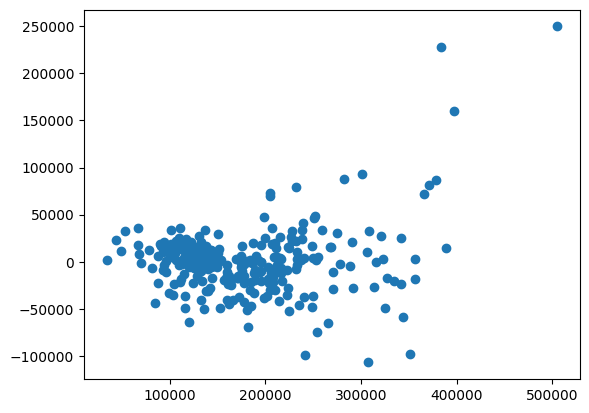

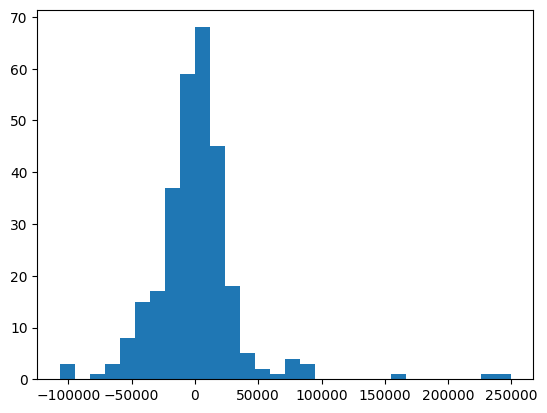

,Metric,Value
0,MAE,2.135049e+04
1,MSE,1.231986e+09
2,RMSE,3.509965e+04
3,R2,8.393829e-01


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
residuals=y_test-y_pred
plt.scatter(y_pred,residuals)
plt.show()
plt.hist(residuals,bins=30)
plt.show()
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
metrics=pd.DataFrame({'Metric':['MAE','MSE','RMSE','R2'],'Value':[mae,mse,rmse,r2]})
display(metrics)

**Task 13**

MAE tells the average absolute dollar amount the predictions are off by without exaggerating large errors MSE squares the errors meaning it heavily penalizes the model for being way off on a few houses RMSE takes the square root of MSE bringing the number back into original dollar units while still keeping the penalty for large mistakes R2 tells the percentage of the variance in the actual house prices that the model can successfully explain I would show MAE to a non technical stakeholder because it is the most intuitive to explain as simply the average dollar amount we expect to be wrong by on any given house

# Part 6 — Training vs. Testing & Generalization

**Task 14**

In [ ]:
train_pred=lr.predict(X_train)
mae_train=mean_absolute_error(y_train,train_pred)
mse_train=mean_squared_error(y_train,train_pred)
rmse_train=np.sqrt(mse_train)
r2_train=r2_score(y_train,train_pred)
comp_df=pd.DataFrame({'Metric':['MAE','MSE','RMSE','R2'],'Train':[mae_train,mse_train,rmse_train,r2_train],'Test':[mae,mse,rmse,r2]})
display(comp_df)

,Metric,Train,Test
0,MAE,2.055474e+04,2.135049e+04
1,MSE,1.053242e+09,1.231986e+09
2,RMSE,3.245368e+04,3.509965e+04
3,R2,8.234164e-01,8.393829e-01


**Task 15**

There is no large gap between the training and testing performance metrics A large gap where training performance is significantly better than testing performance would suggest overfitting meaning the model memorized the training data but fails to generalize to new data Our actual results show the metrics are very close with the test R2 score actually being slightly higher than the train R2 score which suggests the model generalizes very well to new unseen data without any overfitting

# Part 7 — Final Model Analysis, Conclusion & Kaggle Submission

**Task 16**

Looking back at the coefficient table Neighborhood_NoRidge and KitchenQual_TA appear highly influential because their absolute coefficient values are massive however a large coefficient does not automatically mean it is the most important feature because the underlying scales differ for example GrLivArea has a small coefficient of 56 but since it is multiplied by thousands of square feet its actual impact on the final house price is extremely large compared to a simple yes or no category

**Task 17**

The model predicts house prices reasonably well for typical homes but struggles significantly with extreme luxury properties as seen in earlier residual plots RMSE is the most useful metric here because it strongly penalizes large errors which is important when a single bad prediction on an expensive house can be off by hundreds of thousands of dollars OverallQual and GrLivArea have the strongest consistent effect on driving up the predicted price The main limitation of Linear Regression is that it assumes a perfectly straight line relationship and cannot easily handle complex interactions without manual feature engineering Next I would try tree based models like Random Forest or XGBoost which can handle non linear patterns automatically

**Task 18**

In [ ]:
test_df=pd.read_csv('test.csv')
test_subset=test_df[['Id','OverallQual','GrLivArea','TotalBsmtSF','GarageCars','YearBuilt','FullBath','Neighborhood','HouseStyle','KitchenQual','CentralAir']].copy()
test_subset['CentralAir']=test_subset['CentralAir'].map({'Y':1,'N':0})
X_sub=pd.get_dummies(test_subset.drop('Id',axis=1),columns=['Neighborhood','HouseStyle','KitchenQual'],drop_first=True,dtype=int)
X_sub=X_sub.reindex(columns=X.columns,fill_value=0)
X_sub=X_sub.fillna(X_sub.median())
sub_preds=lr.predict(X_sub)
submission=pd.DataFrame({'Id':test_subset['Id'],'SalePrice':sub_preds})
submission.to_csv('submission.csv',index=False)

**Task 19**

My public leaderboard score is 0.16921 and my rank is 3079 Seeing the model measured against thousands of real submissions provided a realistic perspective on how baseline models compare to heavily tuned competition entries while also showing that a simple linear regression can still establish a solid starting point